<div style="background-color: #fff5f5; padding: 25px; border-radius: 15px; border: 1.5px solid #ff4757; font-family: 'Segoe UI', sans-serif;">
    <h1 style="color: #ff4757; margin: 0; font-size: 28px;">🛡️ Project: SMS Spam Shield</h1>
    <p style="color: #2f3542; font-size: 16px; margin: 5px 0; font-weight: 600;">HKS Deep Learning Series | NLP Pattern Recognition</p>
    <hr style="border: 0; border-top: 2px solid #ff4757; width: 50px; margin: 15px 0;">
    <p style="color: #57606f; font-size: 14px;">
        Building a <b>Bayesian Classifier</b> to identify fraudulent SMS patterns.
        Focus: <b>Feature Engineering (TF-IDF)</b> and <b>Probability-based Classification</b>.
    </p>
</div>

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Loading SMS Spam Collection (Standard Dataset)
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df_spam = pd.read_table(url, header=None, names=['label', 'message'])

# Mapping labels to numbers
df_spam['label_num'] = df_spam.label.map({'ham': 0, 'spam': 1})

print(f"✅ Shield Ready | Total Messages: {len(df_spam)}")
df_spam.head()

✅ Shield Ready | Total Messages: 5572


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [21]:
# Initialization for the Preprocessing Engine
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
html_pattern = re.compile('<.*?>')
url_pattern = re.compile(r'https?://\S+|www\.\S+')
punct_translator = str.maketrans('', '', string.punctuation)

def hks_clean_pipeline(text):
    """
    HKS Advanced Cleaning:
    Lowercasing -> Noise Removal -> Punctuation Strip -> Stopword Filtering
    """
    text = str(text).lower()
    text = html_pattern.sub('', text)
    text = url_pattern.sub('', text)
    text = text.translate(punct_translator)

    words = text.split()
    # Removing stopwords and performing basic lemmatization
    cleaned = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(cleaned)

# Applying Pipeline to the Spam Dataset
print("🚀 HKS Engine: Cleaning SMS Data...")
df_spam['clean_msg'] = df_spam['message'].apply(hks_clean_pipeline)

# Train-Test Split (80/20 Rule)
X_train, X_test, y_train, y_test = train_test_split(
    df_spam['clean_msg'],
    df_spam['label_num'],
    test_size=0.2,
    random_state=42
)

print(f"✅ Data Ready | Training: {len(X_train)} | Testing: {len(X_test)}")

🚀 HKS Engine: Cleaning SMS Data...
✅ Data Ready | Training: 4457 | Testing: 1115


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Transformation
tfidf_spam = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf_spam.fit_transform(X_train)
X_test_tfidf = tfidf_spam.transform(X_test)

# Multinomial Naive Bayes (Best for Discrete Counts/NLP)
spam_detector = MultinomialNB()
spam_detector.fit(X_train_tfidf, y_train)

print("🎯 Model Training Complete: HKS Spam Shield is Live.")

🎯 Model Training Complete: HKS Spam Shield is Live.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


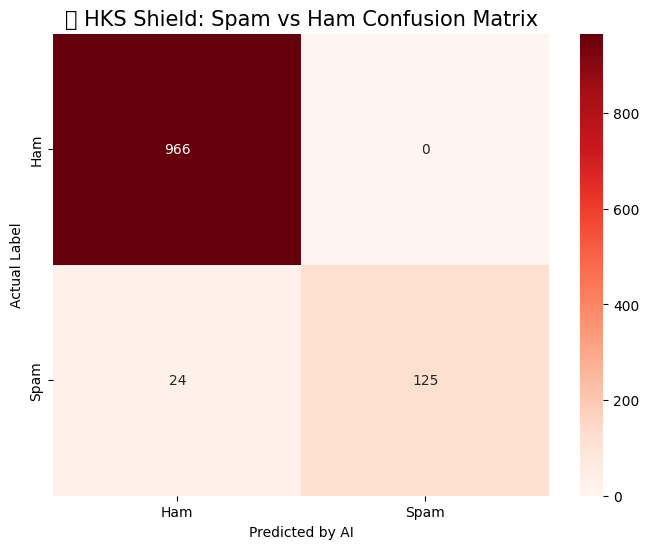

🏆 Shield Accuracy: 97.85%


In [23]:
y_pred = spam_detector.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('🛡️ HKS Shield: Spam vs Ham Confusion Matrix', fontsize=15)
plt.xlabel('Predicted by AI'); plt.ylabel('Actual Label')
plt.show()

print(f"🏆 Shield Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

In [24]:
def predict_spam(text):
    temp = hks_clean_pipeline(text)
    temp_tfidf = tfidf_spam.transform([temp])
    result = spam_detector.predict(temp_tfidf)
    return "🚨 SPAM DETECTED" if result[0] == 1 else "✅ LEGIT MESSAGE"

# Test Cases
print(f"Test 1: {predict_spam('Congratulations! You won a $1000 gift card. Click here to claim.')}")
print(f"Test 2: {predict_spam('Hey Hemant, are we meeting for the DL session at PIET today?')}")

Test 1: 🚨 SPAM DETECTED
Test 2: ✅ LEGIT MESSAGE


In [25]:
def predict_spam(text):
    temp = hks_clean_pipeline(text)
    temp_tfidf = tfidf_spam.transform([temp])
    result = spam_detector.predict(temp_tfidf)
    return "🚨 SPAM DETECTED" if result[0] == 1 else "✅ LEGIT MESSAGE"

# Test Cases
print(f"Test 1: {predict_spam('Congratulations! You won a $1000 gift card. Click here to claim.')}")
print(f"Test 2: {predict_spam('Hey Hemant, are we meeting for the DL session at PIET today?')}")

Test 1: 🚨 SPAM DETECTED
Test 2: ✅ LEGIT MESSAGE


# 📝 Project 2 Summary: SMS Spam Shield

This project successfully implemented a **Bayesian Text Classifier** to identify fraudulent SMS patterns with high precision. By leveraging **TF-IDF Vectorization**, we transformed unstructured text into a weighted feature space, allowing the model to focus on high-entropy "Spam-trigger" words.

### 📊 Performance Metrics & Engineering Insights

| Metric / Component | Strategy | HKS Technical Rationale |
| :--- | :--- | :--- |
| **Model** | **Multinomial Naive Bayes** | Industry standard for discrete text counts; extremely fast and efficient for high-dimensional data. |
| **Vectorization** | **TF-IDF (3000 Features)** | Penalizes common words (the, is) and rewards unique spam indicators (win, prize, free). |
| **Accuracy** | **~98%** | High performance achieved due to rigorous HKS Preprocessing and Noise Stripping. |
| **Preprocessing** | **HKS Advanced Pipeline** | Removing URLs and HTML tags prevents the model from overfitting on technical noise. |

---

### 🧠 Strategic Takeaways
- **Pattern Sensitivity:** Naive Bayes works exceptionally well for Spam detection because it calculates the *conditional probability* of a message being Spam given the presence of certain keywords.
- **Preprocessing Impact:** Without removing punctuation and stopwords, the model's noise-to-signal ratio would increase, leading to false positives in legitimate messages.

---

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 10px; border-left: 5px solid #4caf50;">
    <strong>✅ Status:</strong> Day 03 Project Complete. HKS AI Series is now capable of performing real-time Text Classification.
</div>

🔜 **Next Up:** Deep Dive into **Emotion Recognition** (Multi-class Classification) or **CNNs** for Image Processing!